<a href="https://colab.research.google.com/github/AHMEDVALL70/ahmed-vall-cv/blob/main/Diabetes_Prediction_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Project 01: Diabetes Prediction Model
**Author:** Ahmed Vall Jemal Dine Sidina | AHMEDVALL70

**Goal:** Build a Machine Learning classification model to predict whether a patient is likely to have diabetes based on clinical data.

**Algorithms:** Logistic Regression + Random Forest Classifier

**Dataset:** Pima Indians Diabetes Dataset

---

In [1]:
# ── Step 1: Import Libraries ─────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
# ── Step 2: Load & Explore Dataset ──────────────────────────────
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
        'Insulin','BMI','DiabetesPedigree','Age','Outcome']

df = pd.read_csv(url, names=cols)

print('📊 Dataset Shape:', df.shape)
print('\n📋 First 5 rows:')
print(df.head().to_string())
print('\n📈 Class Distribution:')
print(df['Outcome'].value_counts().rename({0:'No Diabetes', 1:'Diabetes'}).to_string())

📊 Dataset Shape: (768, 9)

📋 First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigree  Age  Outcome
0            6      148             72             35        0  33.6             0.627   50        1
1            1       85             66             29        0  26.6             0.351   31        0
2            8      183             64              0        0  23.3             0.672   32        1
3            1       89             66             23       94  28.1             0.167   21        0
4            0      137             40             35      168  43.1             2.288   33        1

📈 Class Distribution:
No Diabetes    500
Diabetes       268


In [3]:
# ── Step 3: Data Cleaning & Preprocessing ────────────────────────
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in zero_cols:
    df[col] = df[col].replace(0, df[col].median())

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'✅ Data cleaned — zeros replaced with median values')
print(f'✅ Train size : {X_train_sc.shape}')
print(f'✅ Test size  : {X_test_sc.shape}')

✅ Data cleaned — zeros replaced with median values
✅ Train size : (614, 8)
✅ Test size  : (154, 8)


In [4]:
# ── Step 4: Train & Evaluate Models ──────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_sc))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)
rf_preds = rf.predict(X_test_sc)
rf_acc   = accuracy_score(y_test, rf_preds)
rf_auc   = roc_auc_score(y_test, rf.predict_proba(X_test_sc)[:,1])

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'📊 Logistic Regression Accuracy : {lr_acc*100:.2f}%')
print(f'🌳 Random Forest Accuracy       : {rf_acc*100:.2f}%')
print(f'🎯 Random Forest ROC-AUC        : {rf_auc:.4f}')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('\n📋 Classification Report (Random Forest):')
print(classification_report(y_test, rf_preds, target_names=['No Diabetes','Diabetes']))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 Logistic Regression Accuracy : 77.27%
🌳 Random Forest Accuracy       : 79.22%
🎯 Random Forest ROC-AUC        : 0.8541
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📋 Classification Report (Random Forest):
              precision    recall  f1-score   support

 No Diabetes       0.83      0.87      0.85       100
    Diabetes       0.72      0.65      0.68        54

    accuracy                           0.79       154
   macro avg       0.77      0.76      0.77       154
weighted avg       0.79      0.79      0.79       154


In [5]:
# ── Step 5: Predict New Patient ───────────────────────────────────
# Format: [Pregnancies, Glucose, BP, SkinThickness, Insulin, BMI, Pedigree, Age]
new_patient    = np.array([[2, 138, 62, 35, 0, 33.6, 0.127, 47]])
new_patient_sc = scaler.transform(new_patient)

prediction  = rf.predict(new_patient_sc)[0]
probability = rf.predict_proba(new_patient_sc)[0][1]

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('🏥  Patient Prediction Result')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'Result      : {"⚠️  Diabetes Detected" if prediction==1 else "✅  No Diabetes"}')
print(f'Probability : {probability*100:.1f}%')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏥  Patient Prediction Result
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Result      : ⚠️  Diabetes Detected
Probability : 72.0%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


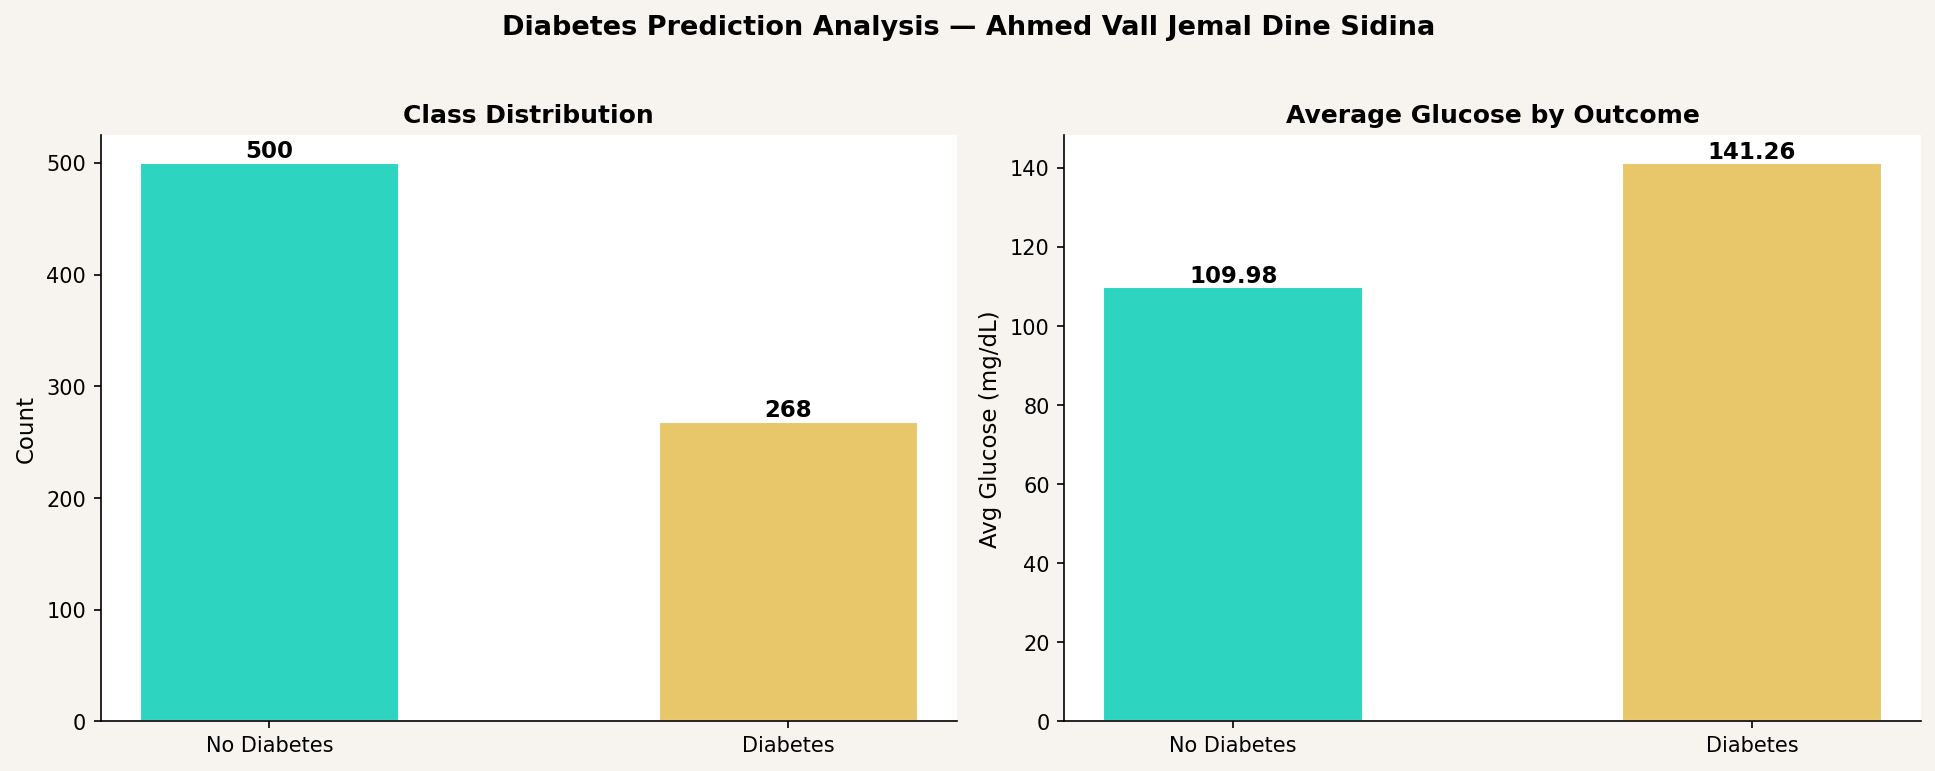


✅ Project 01 — Diabetes Prediction — Completed Successfully!


In [6]:
# ── Step 6: Visualization ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Diabetes Prediction Analysis — Ahmed Vall Jemal Dine Sidina',
             fontsize=13, fontweight='bold')

# Chart 1: Class Distribution
labels = ['No Diabetes', 'Diabetes']
values = [500, 268]
bars1 = axes[0].bar(labels, values, color=['#2dd4bf','#e8c76a'], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars1, values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 str(val), ha='center', fontweight='bold')

# Chart 2: Average Glucose
gluc_vals = [109.98, 141.26]
bars2 = axes[1].bar(labels, gluc_vals, color=['#2dd4bf','#e8c76a'], edgecolor='white', width=0.5)
axes[1].set_title('Average Glucose by Outcome', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Glucose (mg/dL)')
for bar, val in zip(bars2, gluc_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print('\n✅ Project 01 — Diabetes Prediction — Completed Successfully!')